# Introduction

This notebook runs a simple benchmark of [GPU-accelerated HDBSCAN](https://docs.rapids.ai/api/cuml/nightly/api/generated/cuml.cluster.hdbscan.hdbscan/).

# Preparation

## Dependencies

In [1]:
%pip install fast_hdbscan polars pynndescent scipy seaborn tqdm

Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
from cuml.cluster import HDBSCAN as HDBSCAN_GPU
from fast_hdbscan import HDBSCAN as HDBSCAN_CPU
from pynndescent import NNDescent
from scipy.cluster.hierarchy import to_tree
from seaborn import move_legend, relplot
from sklearn.datasets import make_blobs
from time import time
from tqdm.notebook import trange
import matplotlib.pyplot as plt
import polars as pl

## Constants

### Number of `DataFrame` Rows and Columns

In [3]:
NUM_ROWS = [10, 100, 1_000, 10_000, 20_000, 40_000, 100_000, 200_000, 400_000, 1_000_000]
NUM_COLS = [10, 20]
HDBSCAN_FUNCS = [('CPU',HDBSCAN_CPU), ('GPU',HDBSCAN_GPU)]

### Number of Replicates per `DataFrame` Dimensions

In [4]:
NUM_REPS = 5

## Functions

### Compute HDBSCAN Clustering Tree

In [5]:
def compute_hdbscan_tree(data, HDBSCAN=HDBSCAN_GPU):
    model = HDBSCAN(min_cluster_size=2, min_samples=1)
    model.fit(data)
    linkage_matrix = model.single_linkage_tree_.to_numpy()
    root, nodes = to_tree(linkage_matrix, rd=True)
    for i in range(len(nodes)):
        nodes[i].label = f'leaf_{i}'
    return linkage_matrix, root, nodes

### Compute Number of Clusters vs. Height (i.e., distance from leaves)

In [6]:
def compute_clusters_vs_height(nodes, include_singletons=False):
    num_clusters = dict()
    curr_num_clusters = 0
    for node in sorted(nodes, key=lambda x:x.dist):
        if node.is_leaf():
            if include_singletons:
                curr_num_clusters += 1
        else: # internal node
            if include_singletons:
                curr_num_clusters -= 1
            else:
                num_leaf_children = int(node.left.is_leaf()) + int(node.right.is_leaf())
                if num_leaf_children == 0:
                    curr_num_clusters -= 1
                elif num_leaf_children == 2:
                    curr_num_clusters += 1
        num_clusters[node.dist] = curr_num_clusters
    return num_clusters

# Benchmark

## Run Experiment

In [7]:
# set up data structures
list_num_rows = list()
list_num_cols = list()
list_hdbscan_type = list()
list_runtime = list()

# run benchmark
total_runs = len(NUM_ROWS) * len(NUM_COLS) * len(HDBSCAN_FUNCS) * NUM_REPS
for num_rows in NUM_ROWS:
    for num_cols in NUM_COLS:
        for HDBSCAN_type, HDBSCAN_func in HDBSCAN_FUNCS:
            if HDBSCAN_type == 'CPU' and num_rows > 100_000:
                continue # 400,000 x 10 matrix crashed the Python kernel
            for rep in trange(NUM_REPS, desc=f'{HDBSCAN_type}: {num_rows} x {num_cols}'):
                X, y = make_blobs(n_samples=num_rows, n_features=num_cols)
                start_time = time()
                linkage_matrix, root, nodes = compute_hdbscan_tree(X, HDBSCAN=HDBSCAN_func)
                end_time = time()
                list_num_rows.append(num_rows)
                list_num_cols.append(str(num_cols))
                list_hdbscan_type.append(HDBSCAN_type)
                list_runtime.append(end_time - start_time)

# reformat results data as DataFrame
bench_df = pl.DataFrame({
    'Rows': list_num_rows,
    'Columns': list_num_cols,
    'HDBSCAN Type': list_hdbscan_type,
    'Runtime': list_runtime,
})
bench_df

CPU: 10 x 10:   0%|          | 0/5 [00:00<?, ?it/s]

GPU: 10 x 10:   0%|          | 0/5 [00:00<?, ?it/s]

CPU: 10 x 20:   0%|          | 0/5 [00:00<?, ?it/s]

GPU: 10 x 20:   0%|          | 0/5 [00:00<?, ?it/s]

CPU: 100 x 10:   0%|          | 0/5 [00:00<?, ?it/s]

...

GPU: 400000 x 10:   0%|          | 0/5 [00:00<?, ?it/s]

GPU: 400000 x 20:   0%|          | 0/5 [00:00<?, ?it/s]

GPU: 1000000 x 10:   0%|          | 0/5 [00:00<?, ?it/s]

GPU: 1000000 x 20:   0%|          | 0/5 [00:00<?, ?it/s]

Rows,Columns,HDBSCAN Type,Runtime
i64,str,str,f64
10,"""10""","""CPU""",0.145235
10,"""10""","""CPU""",0.072578
10,"""10""","""CPU""",0.112169
10,"""10""","""CPU""",0.073554
10,"""10""","""CPU""",0.084999
…,…,…,…
1000000,"""20""","""GPU""",160.175071
1000000,"""20""","""GPU""",159.463613
1000000,"""20""","""GPU""",160.349406


## Plot Results

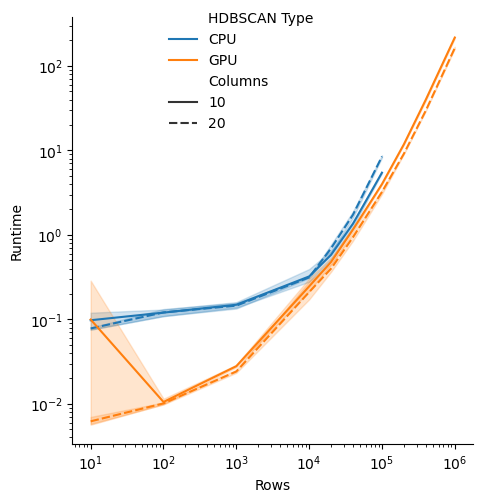

In [8]:
g = relplot(data=bench_df, x='Rows', y='Runtime', hue='HDBSCAN Type', style='Columns', kind='line')
g.set_axis_labels("Rows", "Runtime")
g.set(
    xscale="log",
    yscale="log",
)
move_legend(g, loc="upper center")
plt.savefig("hdbscan_benchmark.pdf", bbox_inches="tight")